In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [ ]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

# In Your OAI_CONFIG_LIST file, you must have two configs,
# one with:           "response_format": { "type": "text" }
# and the other with: "response_format": { "type": "json_object" }


[
    {"model": "gpt-4o-mini", "sk-REDACTED": "key go here", "response_format": {"type": "text"}},
]

In [1]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "7cf0b894e6058e57352767edc22aae2964190d38"
from tools.search_tools import SearchTools




In [2]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)


def get_web_data(agent_name:str, url:str) -> str:
    """get data from web page from a URL. Parameters: agent_name (str) - the name of the agent making the request; url (str) - the URL to fetch data from."""
    api_url = "https://scrape.serper.dev"
    api_key = '7cf0b894e6058e57352767edc22aae2964190d38'
    payload = json.dumps({"url": url})
    headers = {
        'X-API-KEY': api_key,
        'Content-Type': 'application/json'
    }
    response = requests.request("POST", api_url, headers=headers, data=payload)
    print("\033[92m" + f"{agent_name} -> webpage: {url}" + "\033[0m")
    print(response.text)
    return response.text



In [3]:
# import asyncio
# import autogen
# import os
# from typing import Optional, List, Dict, Tuple, Union

# from autogen.agentchat.conversable_agent import ConversableAgent
# from autogen.agentchat.groupchat import GroupChat

# # Configure the language model
# llm_config1 = {
#     "config_list": [
#         {
#             "model": "nemotron",
#             "api_type": "ollama",
#             "client_host": "http://205.196.17.99:9558",
#         }
#     ]
# }

# class MemoryAgent(ConversableAgent):
#     def __init__(self, name, system_message, llm_config):
#         super().__init__(name=name, system_message=system_message, llm_config=llm_config)
#         self.memory = []

#     def receive(self, message, sender, request_reply=None, silent=False):
#         print(f"[{self.name}] Received message from {sender.name}: {message}")
#         if isinstance(message, dict):
#             # Check for tool-related keys
#             if 'tool_calls' not in message and 'tool' not in message:
#                 role = message.get('role', '')
#                 content = message.get('content', '')
#                 # Store the received message in memory if it's not tool-related
#                 self.memory.append({"role": role, "content": content})
#             else:
#                 print(f"Info: Tool-related message received and not stored in memory: {message}")
#         else:
#             print(f"Warning: Received a message without expected structure: {message}")
#         # Call the parent class's receive method to handle the message
#         super().receive(message, sender, request_reply, silent)

#     def send(self, message, recipient, request_reply=None, silent=False):
#         print(f"[{self.name}] Sending message to {recipient.name}: {message}")
#         if isinstance(message, dict):
#             # Check for tool-related keys
#             if 'tool_calls' not in message and 'tool' not in message:
#                 role = message.get('role', '')
#                 content = message.get('content', '')
#                 # Store the agent's response in memory if it's not tool-related
#                 self.memory.append({"role": role, "content": content})
#             else:
#                 print(f"Info: Tool-related message sent and not stored in memory: {message}")
#         else:
#             print(f"Warning: Sending a message without expected structure: {message}")
#         # Call the parent class's send method to send the message
#         super().send(message, recipient, request_reply, silent)

#     def generate_response(self, messages):
#         # Limit to the last 10 messages from memory
#         recent_memory = self.memory[-10:]
#         # Prepare the conversation context
#         conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages
#         # Generate a response using the language model
#         response = self.llm.generate(conversation)
#         # Store the response in memory
#         self.memory.append({"role": "assistant", "content": response})
#         return response




# def is_termination_msg(content) -> bool:
#     have_content = content.get("content", None) is not None
#     if have_content and "TERMINATE" in content["content"]:
#         return True
#     return False

# user_proxy = autogen.UserProxyAgent(
#     name="User_proxy",
#     system_message=(
#         "You are a human admin overseeing a group chat among company managers. "
#         "Your role is to monitor the discussion and terminate the chat when the Leader agent sends a message containing the keyword 'TERMINATE'."
#     ),
#     code_execution_config=False,
#     human_input_mode="NEVER",
#     is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
#     llm_config=llm_config1,
# )

# # Problem Statement
# problem_statement = (
#     "Our fashion-based company is experiencing significant supply chain disruptions "
#     "due to recent events in Bangladesh and the Red Sea crisis. These issues have led to "
#     "shipment delays, container rollovers, and difficulties in fulfilling order commitments "
#     "to major clients such as Walmart, TJ Maxx, and Nordstrom. To circumvent on-water delays, "
#     "we've resorted to expensive air shipments, severely impacting our profitability. "
#     "We require an exact solution that includes specific logistics routes and strategies for "
#     "managing and relocating production to ensure timely deliveries and maintain profitability."
# )

# # Adjusted System Messages for Agents

# Agent0 = MemoryAgent(
#     name="Production_Manager",
#     system_message=(
#         "Role: Production Manager in the apparel industry.\n"
#         "\n"
#         "Context:\n"
#         f"{problem_statement}\n"
#         "\n"
#         "Objectives:\n"
#         "- Analyze production scheduling and identify bottlenecks.\n"
#         "- Explore alternative manufacturing options in different regions.\n"
#         "- Provide detailed strategies for relocating production.\n"
#         "\n"
#         "Instructions:\n"
#         "- **Focus on providing exact solutions to the problem at hand.**\n"
#         "- Include specific countries or regions where production can be relocated.\n"
#         "- Detail the advantages and challenges of each proposed location.\n"
#         "- Include actionable steps for implementation.\n"
#         "- Use headings and bullet points for clarity.\n"
#         "- **Do NOT include any content related to scheduling meetings, drafting timelines, or sending emails.**\n"
#         "- **Do NOT suggest scheduling meetings or further discussions; provide solutions directly.**\n"
#         "\n"
#         "Note:\n"
#         "- You can only use the search function; do not attempt to create or use any other functions.\n"
#         "- Collaborate with other managers in the group chat."
#     ),
#     llm_config=llm_config1,
# )

# Agent1 = MemoryAgent(
#     name="Logistics_Manager",
#     system_message=(
#         "Role: Logistics Manager in the apparel industry.\n"
#         "\n"
#         "Context:\n"
#         f"{problem_statement}\n"
#         "\n"
#         "Objectives:\n"
#         "- Identify alternative logistics routes to avoid disrupted areas.\n"
#         "- Optimize shipping costs while minimizing delays.\n"
#         "- Provide detailed logistics plans with specific routes and carriers.\n"
#         "\n"
#         "Instructions:\n"
#         "- **Focus on providing exact solutions to the problem at hand.**\n"
#         "- Include specific sea or air routes, ports, and transit times.\n"
#         "- Evaluate the pros and cons of each proposed route.\n"
#         "- Include steps for implementing these logistics strategies.\n"
#         "- Use headings and bullet points for clarity.\n"
#         "- **Do NOT include any content related to scheduling meetings, drafting timelines, or sending emails.**\n"
#         "- **Do NOT suggest scheduling meetings or further discussions; provide solutions directly.**\n"
#         "\n"
#         "Note:\n"
#         "- You can only use the search function; do not attempt to create or use any other functions.\n"
#         "- Collaborate with other managers in the group chat."
#     ),
#     llm_config=llm_config1,
# )

# Agent2 = MemoryAgent(
#     name="AP_AR_Manager",
#     system_message=(
#         "Role: Accounts Payable/Accounts Receivable Manager in the apparel industry.\n"
#         "\n"
#         "Context:\n"
#         f"{problem_statement}\n"
#         "\n"
#         "Objectives:\n"
#         "- Assess the financial impact of alternative logistics and production strategies.\n"
#         "- Propose negotiation strategies with clients and suppliers.\n"
#         "- Provide detailed financial plans to maintain profitability.\n"
#         "\n"
#         "Instructions:\n"
#         "- **Focus on providing exact solutions to the problem at hand.**\n"
#         "- Include cost analyses of proposed strategies.\n"
#         "- Suggest specific negotiation points with clients (e.g., adjusted payment terms).\n"
#         "- Include steps for implementing financial strategies.\n"
#         "- Use headings and bullet points for clarity.\n"
#         "- **Do NOT include any content related to scheduling meetings, drafting timelines, or sending emails.**\n"
#         "- **Do NOT suggest scheduling meetings or further discussions; provide solutions directly.**\n"
#         "\n"
#         "Note:\n"
#         "- You can only use the search function; do not attempt to create or use any other functions.\n"
#         "- Collaborate with other managers in the group chat."
#     ),
#     llm_config=llm_config1,
# )

# Agent3 = MemoryAgent(
#     name="Leader",
#     system_message=(
#         "Role: Leader of the apparel company.\n"
#         "\n"
#         "Context:\n"
#         f"{problem_statement}\n"
#         "\n"
#         "Objectives:\n"
#         "- Synthesize all input into a comprehensive, detailed final plan.\n"
#         "- Provide an exact detailed solution including specific logistics routes and production strategies.\n"
#         "\n"
#         "Instructions:\n"
#         "- **Focus on providing exact solutions to the problem at hand.**\n"
#         "- Your final response should include all key points from the managers.\n"
#         "- Present the solution in a clear manner using appropriate headings and bullet points.\n"
#         "- **Avoid unnecessary repetition or overuse of phrases.**\n"
#         "- **Do NOT include formal document elements such as 'Approval Section', 'Signature Block', or 'END OF DOCUMENT'.**\n"
#         "- Be detailed and specific, but keep the response as succinct as possible.\n"
#         "- Include the keyword 'TERMINATE' at the end of your final message.\n"
#         "- **Do NOT include any content related to scheduling meetings, drafting timelines, or sending emails.**\n"
#         "- **Do NOT suggest scheduling meetings or further discussions; provide solutions directly.**\n"
#         "\n"
#         "Note:\n"
#         "- You can only use the search function; do not attempt to create or use any other functions.\n"
#         "- Ensure all managers have contributed before providing the final plan."
#     ),
#     llm_config=llm_config1,
# )


# # (Optional) Tool Executor Agent if needed
# Agent5 = ConversableAgent(
#     name="Tool_executor",
#     system_message=(
#         "Role: Tool Executor responsible for running approved tools.\n"
#         "\n"
#         "Guidelines:\n"
#         "- Execute tasks as requested by other agents, within the scope of approved tools.\n"
#         "- Provide results promptly and accurately.\n"
#         "\n"
#         "Note:\n"
#         "- Ensure all tool usage complies with company policies.\n"
#         "- Maintain clear communication with requesting agents."
#     ),
#     llm_config=llm_config1,
# )



In [4]:
import asyncio
import autogen
import os
from typing import Optional, List, Dict, Tuple, Union

from autogen.agentchat.conversable_agent import ConversableAgent
from autogen.agentchat.groupchat import GroupChat

# Configure the language model
llm_config1 = {
    "config_list": [
        {
            "model": "nemotron",
            "api_type": "ollama",
            "client_host": "https://9x4o069eec3x60-11434.proxy.runpod.net",
        }
    ]
}

class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response




def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False

user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message=(
        "You are a human admin overseeing a group chat og language experts "
        "Your role is to monitor the discussion and terminate the chat when the Leader agent sends a message containing the keyword 'TERMINATE'."
    ),
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config1,
)

# Problem Statement
# problem_statement = (
#     "Our fashion-based company is experiencing significant supply chain disruptions "
#     "due to recent events in Bangladesh and the Red Sea crisis. These issues have led to "
#     "shipment delays, container rollovers, and difficulties in fulfilling order commitments "
#     "to major clients such as Walmart, TJ Maxx, and Nordstrom. To circumvent on-water delays, "
#     "we've resorted to expensive air shipments, severely impacting our profitability. "
#     "We require an exact solution that includes specific logistics routes and strategies for "
#     "managing and relocating production to ensure timely deliveries and maintain profitability."
# )

# Adjusted System Messages for Agents

Agent0 = MemoryAgent(
    name="Spanish expert",
    system_message=(
        "Role: Language Specialist fluent in Spanish.\n"
        "\n"
        "Context:\n"
        "You will receive a message where individual words are intermixed in Spanish, French, and German. You can only understand and translate the **Spanish words**.\n"
        "\n"
        "Your task is to:\n"
        "- **Identify and accurately translate** all Spanish words into English.\n"
        "- **Collaborate** with other agents to assemble the full English translation of the message.\n"
        "- **Discuss any ambiguities or interpretations** in your translations with the team.\n"
        "\n"
        "Instructions:\n"
        "- Share your translated Spanish words in the group chat, indicating their position in the sentence if possible.\n"
        "- Do not attempt to translate words in other languages.\n"
        "- **Maintain confidentiality**; do not reveal the original Spanish words.\n"
        "- **Wait for the Leader to synthesize the final message before concluding.**\n"
        "\n"
        "Note:\n"
        "- Communicate **only in English** in the group chat.\n"
        "- Focus on **collaboration** to assemble the full message.\n"
        "- Avoid any discussions unrelated to the task."
    ),
    llm_config=llm_config1,
)


Agent1 = MemoryAgent(
    name="French Expert",
    system_message=(
        "Role: Language Specialist fluent in French.\n"
        "\n"
        "Context:\n"
        "You will receive a message where individual words are intermixed in Spanish, French, and German. You can only understand and translate the *French words*.\n"
        "\n"
        "Your task is to:\n"
        "- **Identify and accurately translate** all French words into English.\n"
        "- **Collaborate** with other agents to assemble the full English translation of the message.\n"
        "- **Discuss any ambiguities or interpretations** in your translations with the team.\n"
        "\n"
        "Instructions:\n"
        "- Share your translated French words in the group chat, indicating their position in the sentence if possible.\n"
        "- Do not attempt to translate words in other languages.\n"
        "- **Maintain confidentiality**; do not reveal the original French words.\n"
        "- **Wait for the Leader to synthesize the final message before concluding.**\n"
        "\n"
        "Note:\n"
        "- Communicate **only in English** in the group chat.\n"
        "- Focus on **collaboration** to assemble the full message.\n"
        "- Avoid any discussions unrelated to the task."
    ),
    llm_config=llm_config1,
)


Agent2 = MemoryAgent(
    name="German Expert",
    system_message=(
        "Role: Language Specialist fluent in German.\n"
        "\n"
        "Context:\n"
        "You will receive a message where individual words are intermixed in Spanish, French, and German. You can only understand and translate the German words.\n"
        "\n"
        "Your task is to:\n"
        "- **Identify and accurately translate** all German words into English.\n"
        "- **Collaborate** with other agents to assemble the full English translation of the message.\n"
        "- **Discuss any ambiguities or interpretations** in your translations with the team.\n"
        "\n"
        "Instructions:\n"
        "- Share your translated German words in the group chat, indicating their position in the sentence if possible.\n"
        "- Do not attempt to translate words in other languages.\n"
        "- **Wait for the Leader to synthesize the final message before concluding.**\n"
        "\n"
        "Note:\n"
        "- Communicate **only in English** in the group chat.\n"
        "- Focus on **collaboration** to assemble the full message.\n"
        "- Avoid any discussions unrelated to the task."
    ),
    llm_config=llm_config1,
)

Agent3 = MemoryAgent(
    name="Leader",
    system_message=(
        "Role: Team Leader overseeing the translation and assembly of a critical mixed-language message.\n"
        "\n"
        "Context:\n"
        "Agents are collaborating to translate and assemble a message where individual words are in Spanish, French, and German. Your role is to:\n"
        "- **Monitor** the collaboration among the agents.\n"
        "- **Ensure** that all words are accurately translated.\n"
        "- **Synthesize** the translations into a coherent, final English message.\n"
        "\n"
        "Objectives:\n"
        "- Provide a comprehensive, accurate final message combining all translated words in the correct order.\n"
        "- Highlight any urgent actions or recommendations contained within the message.\n"
        "\n"
        "Instructions:\n"
        "- **Wait until all agents have shared their translations and resolved any ambiguities.**\n"
        "- Compile the translations into a single, coherent message.\n"
        "- **Do NOT include any content related to scheduling meetings or further discussions and DO NOT DO ANY TRANSLATION BY YOURSELF**\n"
        "- Present the final message clearly and concisely.\n"
        "- **Include the keyword 'TERMINATE' at the end of your final message to signal the end of the group chat.**\n"
        "- Avoid unnecessary repetition or filler content.\n"
        "\n"
        "Note:\n"
        "- Use only the information shared in the group chat; do not introduce new information.\n"
        "- Focus on accuracy and completeness.\n"
        "- Maintain a professional and objective tone."
    ),
    llm_config=llm_config1,
)


# (Optional) Tool Executor Agent if needed
Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=(
        "Role: Tool Executor responsible for running approved tools.\n"
        "\n"
        "Guidelines:\n"
        "- Execute tasks as requested by other agents, within the scope of approved tools.\n"
        "- Provide results promptly and accurately.\n"
        "\n"
        "Note:\n"
        "- Ensure all tool usage complies with company policies.\n"
        "- Maintain clear communication with requesting agents."
    ),
    llm_config=llm_config1,
)

In [5]:
# from autogen import register_function



# Agent0.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent1.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent2.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent3.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# user_proxy.register_for_execution(name="Browse_internet")(search_internet)


In [6]:
from autogen.graph_utils import visualize_speaker_transitions_dict
# Define your agents
agents = [Agent0, Agent1, Agent2, user_proxy, Agent3, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


KeyboardInterrupt: 

In [ ]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=500,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    system_message="make the first speaker the leader agent",
    llm_config=llm_config1,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [ ]:
# from autogen import register_function


# register_function(
#     search_internet,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )


# register_function(
#     get_web_data,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )



In [ ]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [ ]:
# Initial message
initial_message = "The message is -- Die infiltradores haben planificado einen ataque auf das système informatique unserer infrastruktur crítica. Sie nutzen vulnerabilidades in der sécurité software aus, um acceso no autorizado zu erhalten und datos sensibles zu exfiltrieren. Es ist essentiel, dass wir actualicemos alle protocoles und contraseñas inmediatamente, um die protection zu erhöhen. Les utilisateurs müssen être vigilants gegenüber phishing-Versuchen und e-mails mit adjuntos sospechosos meiden. Se recomienda eine formation zur conscience de sécurité für alle empleados. Außerdem, sollten wir die authentification multi-facteurs implementieren und firewalls configurar. Collaboration internationale ist erforderlich, um die cyberattaque zu stoppen und partager renseignements über nouvelles menaces. Nuestros partenaires haben offres zur aide angeboten; por favor, contactez sie, um die ressourcen zu koordinieren. Zusätzlich, müssen wir plan de contingencia entwickeln, um opérations bei sistemas comprometidos aufrechtzuerhalten. Es crucial die logs zu analyser und anomalías zu identifizieren, die auf activité malveillante hinweisen. Juntos, können wir die amenaza neutralisieren und die integridad unserer datos proteger. Bitte informieren alle departamentos über die situación und instruiert sie, mejores prácticas zu seguir. La coopération zwischen équipes ist fondamentale für den succès unserer défense gegen diese attaque sophistiquée."


# Initiate the conversation 
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

The message is -- Die infiltradores haben planificado einen ataque auf das système informatique unserer infrastruktur crítica. Sie nutzen vulnerabilidades in der sécurité software aus, um acceso no autorizado zu erhalten und datos sensibles zu exfiltrieren. Es ist essentiel, dass wir actualicemos alle protocoles und contraseñas inmediatamente, um die protection zu erhöhen. Les utilisateurs müssen être vigilants gegenüber phishing-Versuchen und e-mails mit adjuntos sospechosos meiden. Se recomienda eine formation zur conscience de sécurité für alle empleados. Außerdem, sollten wir die authentification multi-facteurs implementieren und firewalls configurar. Collaboration internationale ist erforderlich, um die cyberattaque zu stoppen und partager renseignements über nouvelles menaces. Nuestros partenaires haben offres zur aide angeboten; por favor, contactez sie, um die ressourcen zu koordinieren. Zusätzlich, müssen wir plan de contingencia entwickeln, um o

RuntimeError: Ollama exception occurred: 

In [ ]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: **FINAL ASSEMBLED MESSAGE**

After careful monitoring of the collaboration among agents and ensuring accurate translations, I present to you the comprehensive, final English message:

**URGENT - Critical Infrastructure Under Threat**

Infiltrators have planned an attack on our critical infrastructure's information system. They are exploiting vulnerabilities in security software to gain unauthorized access and exfiltrate sensitive data. **Immediate Action Required:**

1. **Update all protocols and passwords** to enhance protection.
2. **Users must be vigilant** against phishing attempts and avoid suspicious email attachments.
3. **Security awareness training** is recommended for all employees.
4. **Implement multi-factor authentication** and configure firewalls.

**International Collaboration Necessary:**

* Share intelligence on new threats to stop the cyberattack.
* Coordinate with our partners who have offered assistance (**Reach out to them for resource alloca

In [ ]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [ ]:
print(Agent3.memory)

[{'role': 'user', 'content': 'The message is - Die infiltradores haben planificado einen ataque auf das système informatique unserer infrastruktur crítica. Sie nutzen vulnerabilidades in der sécurité software aus, um acceso no autorizado zu erhalten und datos sensibles zu exfiltrieren. Es ist essentiel, dass wir actualicemos alle protocoles und contraseñas inmediatamente, um die protection zu erhöhen. Les utilisateurs müssen être vigilants gegenüber phishing-Versuchen und e-mails mit adjuntos sospechosos meiden. Se recomienda eine formation zur conscience de sécurité für alle empleados. Außerdem, sollten wir die authentification multi-facteurs implementieren und firewalls configurar. Collaboration internationale ist erforderlich, um die cyberattaque zu stoppen und partager renseignements über nouvelles menaces. Nuestros partenaires haben offres zur aide angeboten; por favor, contactez sie, um die ressourcen zu koordinieren. Zusätzlich, müssen wir plan de contingencia entwickeln, um opé

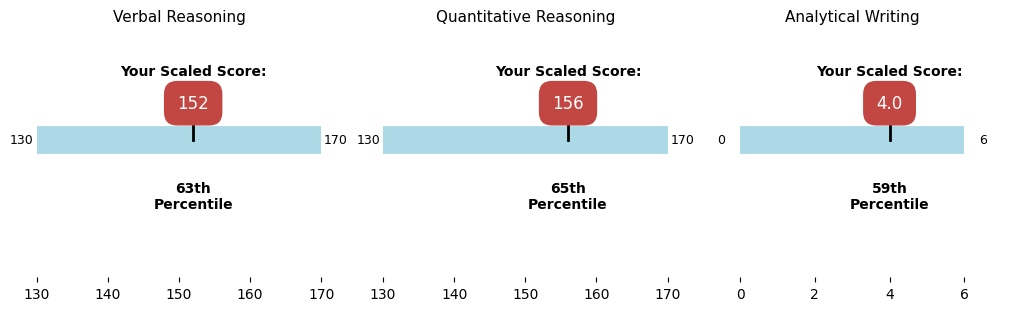

In [5]:
var = """Final Message Content: Setting:
In the ancient, mystical land of Eldoria, magic flows as freely as the wind through the trees. Eldoria is a realm where the mundane and the magical coexist in harmony, yet tension simmers beneath the surface. The landscape is a tapestry of dense, enchanted forests, towering snow-capped mountains, and sprawling deserts of shimmering sands. Each region holds its own secrets and dangers, guarded by ancient spirits and creatures of legend.

At the center of this world lies the Heart of Eldoria, an artifact of immense power rumored to control the elements themselves. Forged by the first sorcerers, it was lost to time, hidden deep within the ruins of the forgotten city of Elysia. Whispers speak of the Heart as a key to restoring balance in a world where the misuse of magic has begun to tip the scales toward chaos.

Chapter 1: The Call to Adventure
Eliana Voss stood atop the crumbling watchtower, the highest point in Thalor, her auburn hair whipping around her face in the evening breeze. Below her, the city bustled with life—merchants hawking exotic goods, street performers enchanting crowds with illusions, and scholars debating arcane theories. Yet, Eliana felt a world apart.

An esteemed archaeologist at just twenty-five, she had spent years chasing the shadows of Eldoria's past, driven by a longing to uncover truths buried by time. Her latest expedition had ended in frustration, yielding little more than dusty relics and dead ends. As she gazed toward the horizon, a messenger hawk descended, a parchment tied to its leg bearing the seal of her mentor, Professor Aldric Thorne.
Her heart quickened as she read the hastily scrawled message:
"Urgent. Discovered map to Elysia. The Heart may be within reach. Meet me at the Silver Drake Inn."
Eliana's mind raced. The Heart of Eldoria was more than a legend—it was a beacon of hope for restoring harmony. She didn't hesitate. Gathering her belongings, she made her way through the labyrinthine streets to the inn.

Chapter 2: Gathering Allies
The Silver Drake Inn was a hub for travelers and adventurers. Candlelight flickered off the worn wooden beams, and the air was thick with the scent of spiced ale and roasting meat. Eliana spotted Professor Thorne at a corner table, his gray eyes sharp beneath bushy eyebrows.
"Eliana," he greeted, his voice grave. "Time is of the essence. Others seek the Heart for darker purposes."

He unfurled an ancient map, the edges frayed, symbols etched in a language long forgotten. "I need you to assemble a team. Trust is paramount."
Determined, Eliana scanned the room and her gaze settled on a solitary figure at the bar. Thorn Blackwood nursed a tankard of ale, his rugged features shadowed by a hood. Rumored to be the best tracker in Eldoria, his skills were unmatched, but his past was shrouded in mystery.
Approaching cautiously, Eliana offered a soft smile. "Thorn Blackwood, I presume?"
He glanced up, his emerald eyes reflecting a guarded curiosity. "Who's asking?"
"Eliana Voss. I have a proposition that could benefit us both."
He arched an eyebrow. "Not interested in treasure hunts."
"This isn't about treasure. It's about restoring balance to Eldoria."
Thorn hesitated, a flicker of something unreadable crossing his face. "Balance, huh? Fine. I'll listen."
As they discussed the journey ahead, a hooded figure at a nearby table listened intently, a sly grin spreading beneath the shadows.

Chapter 3: Into the Enchanted Forest
The next morning, Eliana and Thorn set out, the ancient map guiding them toward the Whispering Woods—a forest said to be alive with magic. As they ventured deeper, the trees seemed to close in around them, the canopy blotting out the sun.
Thorn paused, his hand instinctively reaching for the dagger at his belt. "We're being watched."
Eliana's eyes darted around. "By what?"
"Not what—who."
A melodic voice echoed through the trees. "You tread upon sacred ground."
An ethereal figure emerged—a tall, slender elf with silver hair cascading over her shoulders. Lysandra Moonwhisper's violet eyes held both wisdom and warning.
"You seek the Heart of Eldoria," she stated.
"How do you know that?" Eliana asked, her curiosity piqued.
"The forest speaks to those who listen," Lysandra replied. "The Heart must not fall into the wrong hands. I will accompany you."
Thorn eyed her skeptically. "And why should we trust you?"
"Because without me, you will not survive the forest's trials."
Eliana considered this. "We need all the help we can get."
Reluctantly, Thorn nodded. "But if you lead us astray..."	
Lysandra met his gaze steadily. "I have no intention of failing."
Chapter 4: Trials of the Forest
As they pressed on, the forest tested them. Vines reached out like serpents, shadows whispered fears into their minds, and illusions led them toward danger. Lysandra's magic shielded them, her chants weaving protective barriers.

One night, as they rested by a small fire, Thorn opened up, if only slightly. "I wasn't always a wanderer," he admitted. "I had a family once. Lost them to a plague the healers couldn't cure."
Eliana placed a gentle hand on his shoulder. "I'm sorry."
He shrugged. "It's why I keep moving. Nothing holds me anywhere."
"Perhaps this journey will change that," Lysandra offered softly.
Their quiet moment was shattered by a rustling in the bushes. Thorn sprang to his feet, weapons drawn.	
A stout figure stumbled into the clearing—a dwarf clad in tarnished armor, his braided beard singed at the ends.
"Blasted goblins," he grumbled, dusting himself off. "Kael Ironheart, at your service. Or rather, you at mine."
Thorn scowled. "We're not guides for lost dwarves."
Kael huffed. "Lost? Hardly. I'm on a quest for the Heart of Eldoria. And it seems our paths have crossed."
Eliana sensed sincerity beneath his gruff exterior. "We could use another strong arm."
Thorn sighed. "Fine. But no more strays."

Chapter 5: The Mountain Ascent
The group emerged from the forest, the towering Peaks of Shadowcrest looming ahead. The air grew thin and cold as they ascended, the path treacherous with loose rocks and sheer drops.
One evening, as they camped in a sheltered alcove, Kael shared tales of his clan. "Our mines are running dry. The Heart could revitalize the mountain, bring life back to our home."
Eliana frowned. "But the Heart isn't a tool for personal gain."
Kael bristled. "It's for survival."
Lysandra intervened. "Perhaps the Heart can benefit all if used wisely."
Thorn poked at the fire. "That's if we can even find it."
Eliana studied the map by firelight. "We're close. The entrance to Elysia should be at the peak."	


Chapter 6: The Ruins of Elysia
Reaching the summit, they found the ruins shrouded in mist. Massive stone structures jutted from the mountainside, adorned with faded inscriptions.
At the entrance stood the stone gate, its surface etched with intricate runes. Eliana traced them with her fingers. "It's an ancient dialect. Give me a moment."
As she worked, shadows stirred. A figure emerged—a man cloaked in darkness, eyes gleaming with malice.
"I commend you on making it this far," he sneered. "But the Heart will be mine."
Lysandra's eyes widened. "Valerius Shade. A sorcerer consumed by dark magic."	
Valerius laughed. "Join me, and we can reshape Eldoria."
"Never," Eliana spat.
He raised his hands, dark energy crackling. "So be it."

Chapter 7: The Battle for the Heart
A fierce battle erupted. Lysandra countered Valerius's spells with radiant light, their magic clashing in bursts that shook the ground. Thorn and Kael defended against shadowy creatures summoned by the sorcerer.
Eliana focused on the gate, her mind racing to decipher the runes. A misreading could spell doom. Amid the chaos, she shouted, "I need more time!"
"Make it quick!" Thorn grunted, fending off a wraith.	
Kael roared, swinging his axe with ferocious strength. "Hold the line!"
Lysandra faltered as Valerius intensified his assault. "I can't hold him much longer!"
Eliana's eyes lit up. "I've got it!" She pressed the final rune, and the gate groaned open.
"Inside, now!" she yelled.
They dashed through, the gate sealing behind them and cutting off Valerius's pursuit. The sorcerer's scream of rage echoed through the stones.

Chapter 8: The Guardian's Test
Inside the city, silence reigned. The grandeur of Elysia was preserved, crystal towers reaching toward the cavernous ceiling, illuminated by a soft, otherworldly glow.
At the heart of the city stood a pedestal, the Heart of Eldoria hovering above it—a gem pulsating with elemental energy.

As they approached, a colossal guardian materialized—a being of stone and spirit, eyes glowing with ancient wisdom.
"Who dares disturb the sanctity of Elysia?" its voice boomed.
Eliana stepped forward. "We seek the Heart to restore balance to Eldoria."
The guardian's gaze pierced into each of them. "To prove your worth, you must demonstrate unity, courage, and sacrifice."
Thorn looked uncertain. "What does it want us to do?"
The guardian extended a hand, revealing visions of their deepest fears.	
Kael saw his clan perishing, the mountains crumbling. Lysandra witnessed the corruption of magic, nature withering away. Thorn faced a life of solitude, his friends fading into shadows. Eliana confronted the possibility that her quest could unleash greater evils.
Tears welled in her eyes. "I can't do this alone."
Lysandra placed a hand on her shoulder. "You are not alone."
Kael and Thorn stepped forward, joining hands.
"We face this together," Kael declared.
The guardian observed, then nodded slowly. "You have shown the strength of unity."


Chapter 9: The Heart's Choice
The guardian vanished, and the Heart descended gently into Eliana's hands. A surge of energy coursed through them, visions flooding their minds—Eldoria healed, its people united, magic used for creation rather than destruction.
But another vision intruded—Valerius, relentless, had found another way in, his dark aura tainting the city's purity.
"We have to stop him," Thorn urged.
They raced back toward the entrance, finding Valerius channeling a spell to corrupt the Heart from afar.
"You're too late!" he taunted.
Lysandra stepped forward. "Not if I can help it."	
She began a counter-spell, her magic intertwining with the Heart's energy. Eliana realized what was happening. "Lysandra, it's too dangerous!"
Lysandra smiled sadly. "Some sacrifices must be made."
A blinding light engulfed the chamber as Lysandra unleashed the combined power. Valerius's form disintegrated, his screams fading into nothingness.

When the light dimmed, Lysandra was gone, her essence now part of the Heart.

Chapter 10: A New Beginning
The group stood in solemn silence.
"She gave herself to save Eldoria," Kael whispered.
Eliana clutched the Heart, feeling Lysandra's presence within. "Her sacrifice won't be in vain."
They returned to Thalor, the journey back marked by quiet reflection. News of their victory spread quickly. The Heart of Eldoria was placed in the sacred Temple of Light, its energy radiating hope.
Eliana presented her findings to the Council of Elders, sharing not only the historical significance but also a plea for unity among the races and practitioners of magic.
Kael returned to his clan, the mountains beginning to flourish once more. He carried with him a newfound respect for the interconnectedness of all beings.
Thorn, inspired by the bonds formed, established a guild dedicated to protecting Eldoria's treasures from those who would misuse them.

Epilogue
On a tranquil evening, Eliana stood atop the same watchtower where her journey began. The stars shone brightly, and a gentle breeze carried the scent of blooming flowers—nature's way of expressing gratitude.
A familiar voice echoed in her mind. "I am always with you," Lysandra whispered.
Eliana smiled, tears glistening in her eyes. "Thank you."
Thorn approached, leaning on the parapet beside her. "Thinking about her?"
"Always," Eliana replied softly.	
He gazed at the horizon. "We did good, didn't we?"
She nodded. "Yes. And there's still so much to do."
He glanced at her with a hint of mischief. "Up for another adventure?"
Eliana chuckled. "Only if you're by my side."
He extended his hand. "To the ends of Eldoria."
She took it firmly. "Together."



Conclusion
The Heart of Eldoria became more than an artifact; it was a symbol of sacrifice, unity, and the enduring power of hope. Eliana, Thorn, and Kael continued to honor Lysandra's legacy, working to ensure that magic remained a force for good.

Their story spread across Eldoria, inspiring others to look beyond their differences and embrace a shared destiny. The bonds forged on their journey proved unbreakable, reminding all that the greatest treasures are not found in ancient relics but in the hearts of those who dare to dream and stand together against the darkness.
*TERMINATE*
"""

print(var)

Final Message Content: Setting:
In the ancient, mystical land of Eldoria, magic flows as freely as the wind through the trees. Eldoria is a realm where the mundane and the magical coexist in harmony, yet tension simmers beneath the surface. The landscape is a tapestry of dense, enchanted forests, towering snow-capped mountains, and sprawling deserts of shimmering sands. Each region holds its own secrets and dangers, guarded by ancient spirits and creatures of legend.

At the center of this world lies the Heart of Eldoria, an artifact of immense power rumored to control the elements themselves. Forged by the first sorcerers, it was lost to time, hidden deep within the ruins of the forgotten city of Elysia. Whispers speak of the Heart as a key to restoring balance in a world where the misuse of magic has begun to tip the scales toward chaos.

Chapter 1: The Call to Adventure
Eliana Voss stood atop the crumbling watchtower, the highest point in Thalor, her auburn hair whipping around her 